In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
df=pd.read_csv(r"C:\Users\Sarvesh\Downloads\FuelConsumption (1) - FuelConsumption (1).csv.csv")

In [215]:
df.shape

(639, 10)

In [216]:
df.head()

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,10.5,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,9.8,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              639 non-null    int64  
 1   MAKE              639 non-null    object 
 2   MODEL             639 non-null    object 
 3   VEHICLE CLASS     639 non-null    object 
 4   ENGINE SIZE       639 non-null    float64
 5   CYLINDERS         639 non-null    int64  
 6   TRANSMISSION      639 non-null    object 
 7   FUEL              639 non-null    object 
 8   FUEL CONSUMPTION  639 non-null    float64
 9   COEMISSIONS       639 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 50.1+ KB


In [218]:
df.columns

Index(['Year', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'COEMISSIONS'],
      dtype='object')

In [219]:
df.isnull().sum()

Year                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
COEMISSIONS         0
dtype: int64

Numeric columns: Index(['Year', 'ENGINE SIZE', 'CYLINDERS', 'FUEL CONSUMPTION', 'COEMISSIONS'], dtype='object')


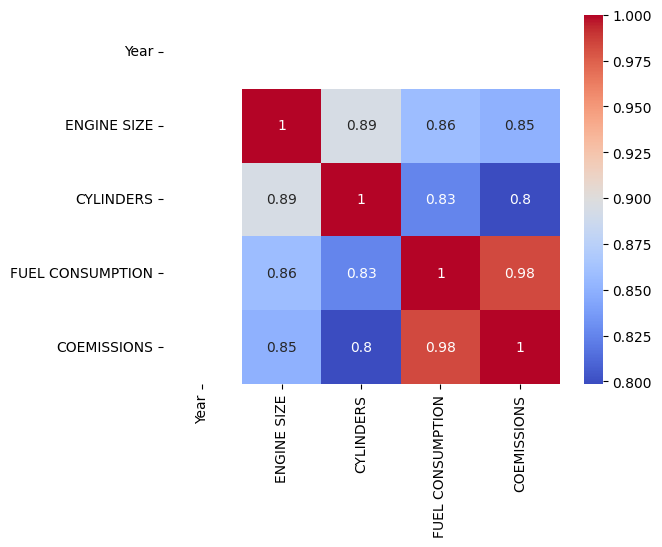

In [220]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns:", numeric_cols)
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True,cmap='coolwarm')
plt.show()

In [221]:
#Independent features and dependent features
X = df.drop(columns=['FUEL CONSUMPTION'])
Y = df['FUEL CONSUMPTION']


In [222]:
X

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,230
...,...,...,...,...,...,...,...,...,...
634,2000,VOLVO,V70 AWD TURBO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,288
635,2000,VOLVO,V70 GLT TURBO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,274
636,2000,VOLVO,V70 T5 TURBO,STATION WAGON - MID-SIZE,2.3,5,A4,Z,274
637,2000,VOLVO,V70 T5 TURBO,STATION WAGON - MID-SIZE,2.3,5,M5,Z,260


In [223]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           639 non-null    int64  
 1   MAKE           639 non-null    object 
 2   MODEL          639 non-null    object 
 3   VEHICLE CLASS  639 non-null    object 
 4   ENGINE SIZE    639 non-null    float64
 5   CYLINDERS      639 non-null    int64  
 6   TRANSMISSION   639 non-null    object 
 7   FUEL           639 non-null    object 
 8   COEMISSIONS    639 non-null    int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 45.1+ KB


In [224]:
from sklearn.preprocessing import LabelEncoder

# Create a label encoder object
label_encoder = LabelEncoder()

X['MAKE'] = label_encoder.fit_transform(df['MAKE'])
X['MODEL']=label_encoder.fit_transform(df['MODEL'])
X['VEHICLE CLASS'] = label_encoder.fit_transform(df['VEHICLE CLASS'])
X['TRANSMISSION'] = label_encoder.fit_transform(df['TRANSMISSION'])
X['FUEL'] = label_encoder.fit_transform(df['FUEL'])
X
#Label encoder assign an integer to each unique category

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,COEMISSIONS
0,2000,0,0,0,1.6,4,1,3,216
1,2000,0,0,0,1.6,4,6,3,205
2,2000,0,1,2,3.2,6,4,4,265
3,2000,0,2,2,3.5,6,1,4,301
4,2000,0,164,9,1.8,4,1,3,230
...,...,...,...,...,...,...,...,...,...
634,2000,35,303,7,2.4,5,1,4,288
635,2000,35,304,7,2.4,5,1,4,274
636,2000,35,305,7,2.3,5,1,4,274
637,2000,35,305,7,2.3,5,6,4,260


In [ ]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.23)
#X_train and Y_test are basically used for traning the data
#X_test and Y_test are used to test the data which is used for validation

In [226]:
X_train

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,COEMISSIONS
581,2000,33,301,6,4.7,8,1,3,382
104,2000,5,160,1,3.8,6,1,3,262
546,2000,33,66,2,3.0,6,1,3,267
256,2000,10,150,1,4.6,8,1,3,297
102,2000,5,140,13,5.7,8,1,3,426
...,...,...,...,...,...,...,...,...,...
147,2000,6,221,9,2.4,4,6,3,269
333,2000,13,33,0,1.5,4,1,3,209
373,2000,18,265,0,1.8,4,1,3,235
0,2000,0,0,0,1.6,4,1,3,216


In [227]:
#now to implement linear regreassion..import it from sklearn.linear_model
#to standardize the data we will use StandadScalar
#standard scalar is in presprocessing so we hv to import it from there
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [228]:
X_train=scaler.fit_transform(X_train)

In [229]:
X_test=scaler.transform(X_test)
#fit_transform is used on training data to learn parameters and transform it, 
# while transform is used on new or unseen data to apply previously 
# learned transformations without re-learning the parameters.

In [230]:
scaler.inverse_transform(X_train)

array([[2.00e+03, 3.30e+01, 3.01e+02, ..., 1.00e+00, 3.00e+00, 3.82e+02],
       [2.00e+03, 5.00e+00, 1.60e+02, ..., 1.00e+00, 3.00e+00, 2.62e+02],
       [2.00e+03, 3.30e+01, 6.60e+01, ..., 1.00e+00, 3.00e+00, 2.67e+02],
       ...,
       [2.00e+03, 1.80e+01, 2.65e+02, ..., 1.00e+00, 3.00e+00, 2.35e+02],
       [2.00e+03, 0.00e+00, 0.00e+00, ..., 1.00e+00, 3.00e+00, 2.16e+02],
       [2.00e+03, 2.00e+00, 1.90e+01, ..., 2.00e+00, 4.00e+00, 3.08e+02]])

In [231]:
X_train

array([[ 0.        ,  1.45885881,  1.57459074, ..., -0.78128129,
        -0.45890602,  1.27046631],
       [ 0.        , -1.00558671,  0.02756454, ..., -0.78128129,
        -0.45890602, -0.55303291],
       [ 0.        ,  1.45885881, -1.00378626, ..., -0.78128129,
        -0.45890602, -0.47705378],
       ...,
       [ 0.        ,  0.13862014,  1.17960533, ..., -0.78128129,
        -0.45890602, -0.96332024],
       [ 0.        , -1.44566627, -1.72792618, ..., -0.78128129,
        -0.45890602, -1.25204095],
       [ 0.        , -1.26963445, -1.51946166, ..., -0.35642395,
         1.44045501,  0.14597512]])

In [232]:
#we will use cross validation here..which internally divides out training data into mutiple train test and cross validates
#it..each cross validation have different different accuracy,combine it and calculate its mean to get te final output 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [233]:
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [234]:
mse=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=5)
#scoring parameter is for accuracy
#cv=5 5 different different data ke sth same model train hoga.

In [235]:
np.mean(mse)

np.float64(-0.2515254008565003)

In [236]:
#scoring parameter is for accuracy
#cv=5 5 different different values ke sth same model train hoga..
mse = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=5)
print(mse)

[-0.68458754 -0.1401691  -0.15937846 -0.15867283 -0.11481907]


In [237]:
np.mean(mse)

np.float64(-0.2515254008565003)

In [238]:
#predicting the test data
reg_predict = regression.predict(X_test)

In [239]:
reg_predict

array([25.80778981, 18.81026014, 12.29965081, 14.11492381,  7.7550398 ,
       11.49596518, 11.1672994 , 12.60374979, 11.6862882 , 11.80049774,
       10.95664781, 13.35850549, 15.58898024, 14.57772371, 11.36975542,
       13.90713531, 19.33855548, 18.49272384, 12.06140441, 17.87433683,
       10.57236356, 11.53154486, 17.79079295, 11.98006427, 16.81386913,
       11.36865845, 15.9389584 , 14.26683841, 13.88778545, 12.24050788,
       11.15298723, 21.1701241 , 14.47585524, 12.1237962 , 18.84867423,
       17.32797733, 11.21799952, 20.95359368, 17.40263579, 13.33343797,
       13.80259381, 15.71893134, 11.55612424, 15.86779668, 14.84689513,
       15.36376147, 13.01984564, 13.59789101, 18.31333392, 18.27491984,
       13.34666836, 17.45816078, 11.90977426, 15.04275315, 11.71118429,
       11.26983258, 16.34413741, 19.8429606 ,  9.22065311, 15.78027858,
       16.91684218, 23.18798444,  7.69496982, 11.59208493, 10.00717238,
       16.85826452, 18.77869368, 14.01754431, 14.15291108, 15.07

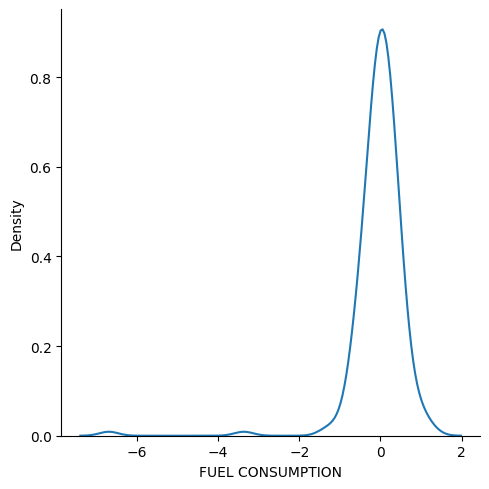

In [240]:
import seaborn as sns
sns.displot(reg_predict-y_test,kind='kde')